# Redes Neurais — "Hello World"
O exemplo mais simples possível: uma rede com **um único neurônio** que aprende a relação entre dois números. Damos alguns pares (x, y) que seguem a regra **y = 2x − 1** e deixamos a rede descobrir sozinha essa regra a partir dos dados.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # silencia logs do TensorFlow
import logging, warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


### Os dados
Seis pontos. Repare que cada `y` é igual a `2*x - 1`.

In [2]:
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0])
for x, y in zip(xs, ys):
    print(f'x={x:+.0f}  ->  y={y:+.0f}')

x=-1  ->  y=-3
x=+0  ->  y=-1
x=+1  ->  y=+1
x=+2  ->  y=+3
x=+3  ->  y=+5
x=+4  ->  y=+7


### A rede
`Dense(1)` é uma única camada com **1 neurônio**. Ele tem só dois parâmetros para aprender: um peso (que deveria virar ~2) e um viés/bias (que deveria virar ~-1).

- **loss = mean_squared_error**: mede o erro entre o que a rede previu e o valor certo.
- **optimizer = sgd**: o algoritmo que ajusta os parâmetros para diminuir esse erro.

In [3]:
model = keras.Sequential([keras.Input(shape=(1,)), layers.Dense(units=1)])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### Treinando (500 épocas)
Cada **época** = uma passada por todos os dados, ajustando um pouco os parâmetros.

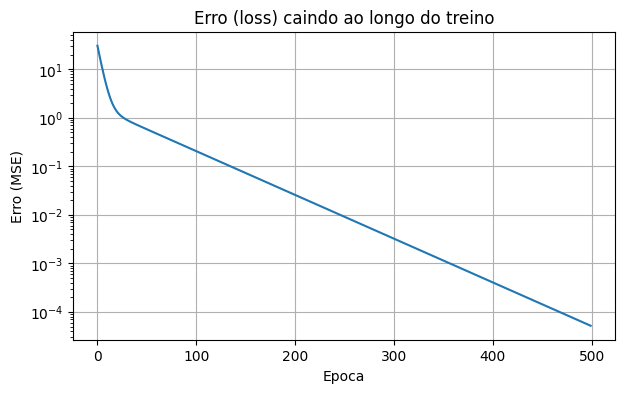

In [4]:
history = model.fit(xs, ys, epochs=500, verbose=0)
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'])
plt.title('Erro (loss) caindo ao longo do treino')
plt.xlabel('Epoca'); plt.ylabel('Erro (MSE)'); plt.grid(True)
plt.yscale('log'); plt.show()

### Testando
Se a regra é y = 2x − 1, então para x = 10 esperamos y = **19**. A rede nunca viu o número 10 — ela responde com base no que aprendeu.

In [5]:
pred = model.predict(np.array([10.0]), verbose=0)
print(f'Previsao para x=10: {float(pred[0][0]):.4f}  (esperado: 19)')
w, b = model.layers[0].get_weights()
print(f'Peso aprendido: {float(w[0][0]):.3f} (perto de 2) | Bias: {float(b[0]):.3f} (perto de -1)')

Previsao para x=10: 18.9790  (esperado: 19)
Peso aprendido: 1.997 (perto de 2) | Bias: -0.991 (perto de -1)


**O que isso mostra:** a rede não recebeu a fórmula — ela **inferiu** a relação a partir dos exemplos, ajustando peso e bias até o erro ficar mínimo. É exatamente essa ideia, em escala muito maior e com muitos neurônios, que faz redes neurais classificarem textos, imagens, etc.